# Financial Crimes & Anomaly Detection Pipeline

**Unsupervised fraud detection with Isolation Forest**

Dataset: [Kaggle Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) — 284,807 real, anonymized European card transactions, 492 of which are confirmed fraud (0.17%).

This notebook builds an **unsupervised** anomaly detection model (no fraud labels used during training) and evaluates how well it separates fraud from legitimate activity, then quantifies the operational tradeoff between catching more fraud and the resulting review workload.

**Pipeline:**
1. Load & explore the data
2. Preprocess (scale `Time`/`Amount`; `V1`-`V28` are already PCA-transformed)
3. Train an Isolation Forest
4. Evaluate with ROC-AUC
5. Quantify the precision/recall tradeoff across flagging thresholds


## 1. Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, confusion_matrix

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('creditcard.csv')
df.shape

(284807, 31)

In [2]:
df['Class'].value_counts()

Class\n0    284315\n1       492\nName: count, dtype: int64

## 2. Exploratory Data Analysis

The dataset is extremely imbalanced — fraud makes up only **0.173%** of all transactions. This is the core challenge: a model that predicts "legitimate" for everything is 99.8% accurate and completely useless.

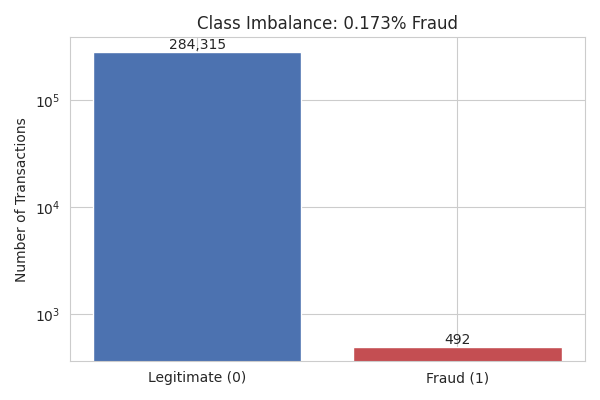

In [3]:
fig, ax = plt.subplots(figsize=(6,4))
counts = df['Class'].value_counts()
ax.bar(['Legitimate (0)', 'Fraud (1)'], counts.values, color=['#4C72B0','#C44E52'])
for i, v in enumerate(counts.values):
    ax.text(i, v, f"{v:,}", ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Number of Transactions')
ax.set_title(f'Class Imbalance: {counts[1]/counts.sum()*100:.3f}% Fraud')
ax.set_yscale('log')
plt.tight_layout()
plt.show()

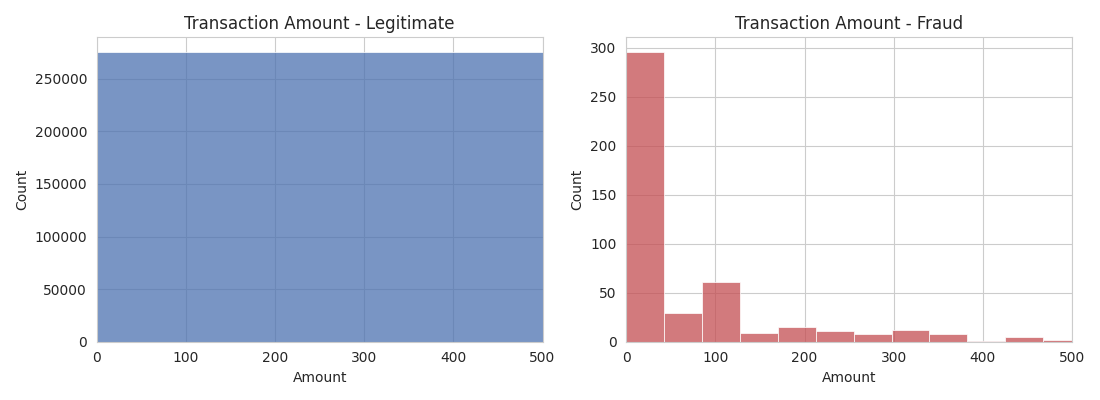

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11,4))
sns.histplot(df[df.Class==0]['Amount'], bins=50, ax=axes[0], color='#4C72B0')
axes[0].set_title('Transaction Amount - Legitimate')
axes[0].set_xlim(0, 500)
sns.histplot(df[df.Class==1]['Amount'], bins=50, ax=axes[1], color='#C44E52')
axes[1].set_title('Transaction Amount - Fraud')
axes[1].set_xlim(0, 500)
plt.tight_layout()
plt.show()

Fraudulent transactions skew toward smaller amounts, but there's meaningful overlap with legitimate spending — amount alone isn't a reliable fraud signal, which is why we rely on the full 28-dimensional PCA feature space.

## 3. Preprocessing

`V1`-`V28` are already PCA-transformed and scaled. `Time` and `Amount` are the two raw features, so we standardize them to match the scale of the rest.

In [5]:
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled'] = scaler.fit_transform(df[['Time']])

feature_cols = [c for c in df.columns if c.startswith('V')] + ['Amount_scaled', 'Time_scaled']
X = df[feature_cols]
y = df['Class']

contamination = float(y.mean())
print(f"Using contamination = {contamination:.6f} (true fraud rate)")

Using contamination = 0.001727 (true fraud rate)\n

## 4. Train Isolation Forest

Isolation Forest is an unsupervised anomaly detection algorithm: it builds an ensemble of random trees and isolates points based on how few splits it takes to separate them. Anomalies (fraud) tend to be isolated in fewer splits than normal points, since they're outliers in feature space.

**Crucially, `y` (the fraud label) is never passed to `.fit()`** — the model learns structure purely from the transaction features. We only use `y` afterward, to *evaluate* what the model found.

In [6]:
iso = IsolationForest(
    n_estimators=200,
    contamination=contamination,
    random_state=42,
    n_jobs=-1
)
iso.fit(X)

# decision_function: higher = more "normal". Flip sign so higher score = more anomalous
scores = -iso.decision_function(X)
preds = iso.predict(X)              # -1 = anomaly, 1 = normal
preds_binary = (preds == -1).astype(int)

print("Model trained on", X.shape[0], "transactions,", X.shape[1], "features")

Model trained on 284807 transactions, 30 features\n

## 5. Evaluation: ROC-AUC

In [7]:
auc = roc_auc_score(y, scores)
print(f"ROC-AUC: {auc:.4f}")

ROC-AUC: 0.9474\n

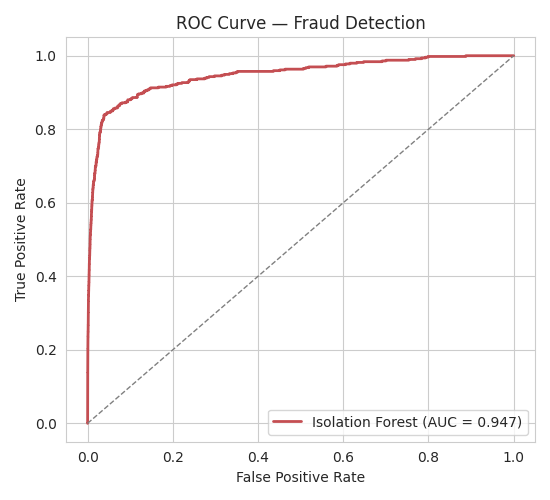

In [8]:
fpr, tpr, _ = roc_curve(y, scores)
fig, ax = plt.subplots(figsize=(5.5,5))
ax.plot(fpr, tpr, color='#C44E52', lw=2, label=f'Isolation Forest (AUC = {auc:.3f})')
ax.plot([0,1],[0,1], linestyle='--', color='gray', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Fraud Detection')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

A ROC-AUC of **0.947** despite training on zero labeled fraud examples means the anomaly score alone ranks fraud well above legitimate transactions most of the time. But AUC hides an important operational reality — that's where the precision/recall tradeoff below comes in.

## 6. The Real Cost: Precision/Recall Tradeoff

AUC is a good ranking metric, but a fraud team doesn't operate on AUC — they operate on a **review queue**: every transaction flagged for review costs analyst time. The question that matters operationally is: *how much does the review queue grow as we push for higher fraud recall?*

For each recall target, we find the score threshold that achieves it, then measure how many transactions get flagged and how many of those are actually fraud (precision).

In [9]:
prec, rec, thresh = precision_recall_curve(y, scores)
n_fraud = int(y.sum())

rows = []
for target in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    idx = np.argmin(np.abs(rec - target))
    t = thresh[idx] if idx < len(thresh) else thresh[-1]
    flagged = int((scores >= t).sum())
    caught = int(((scores >= t) & (y == 1)).sum())
    rows.append(dict(
        target_recall=target,
        flagged=flagged,
        caught=caught,
        recall=round(caught / n_fraud, 3),
        precision=round(caught / max(flagged, 1), 4),
        queue_multiple=round(flagged / n_fraud, 1)
    ))

tradeoff_df = pd.DataFrame(rows)
tradeoff_df

   target_recall  flagged  caught  recall  precision  queue_multiple\n0            0.3      642     148   0.301     0.2305             1.3\n1            0.4     1189     197   0.400     0.1657             2.4\n2            0.5     1959     246   0.500     0.1256             4.0\n3            0.6     3267     295   0.600     0.0903             6.6\n4            0.7     5870     344   0.699     0.0586            11.9\n5            0.8     9206     394   0.801     0.0428            18.7\n6            0.9    38037    443   0.900     0.0116            77.3

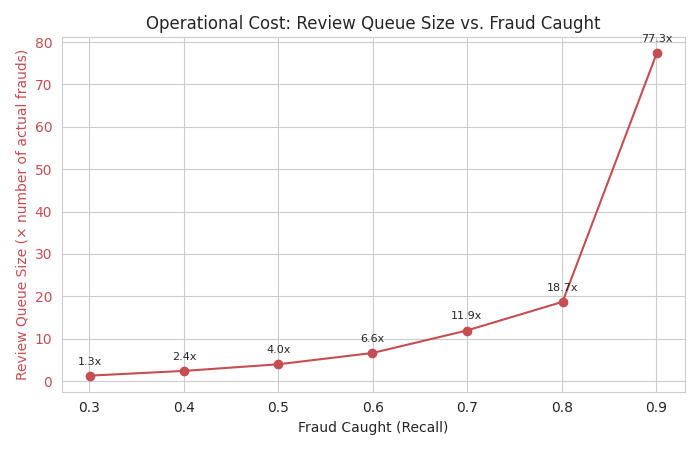

In [10]:
fig, ax1 = plt.subplots(figsize=(7,4.5))
ax1.plot(tradeoff_df['recall'], tradeoff_df['queue_multiple'], marker='o', color='#C44E52')
ax1.set_xlabel('Fraud Caught (Recall)')
ax1.set_ylabel('Review Queue Size (× number of actual frauds)', color='#C44E52')
ax1.tick_params(axis='y', labelcolor='#C44E52')
for _, r in tradeoff_df.iterrows():
    ax1.annotate(f"{r.queue_multiple:.1f}x", (r.recall, r.queue_multiple),
                 textcoords="offset points", xytext=(0,8), fontsize=8, ha='center')
ax1.set_title('Operational Cost: Review Queue Size vs. Fraud Caught')
plt.tight_layout()
plt.show()

**Key finding:** catching **80% of fraud requires flagging ~9,200 transactions** — about **18.7x** the number of actual fraud cases (492) — for a review team to work through. Pushing to 90% recall blows the queue up to **77x**, for a marginal 10-point recall gain. This is the real cost curve a fraud-ops team has to weigh: recall targets set staffing and false-positive-tolerance requirements, not just a model metric.

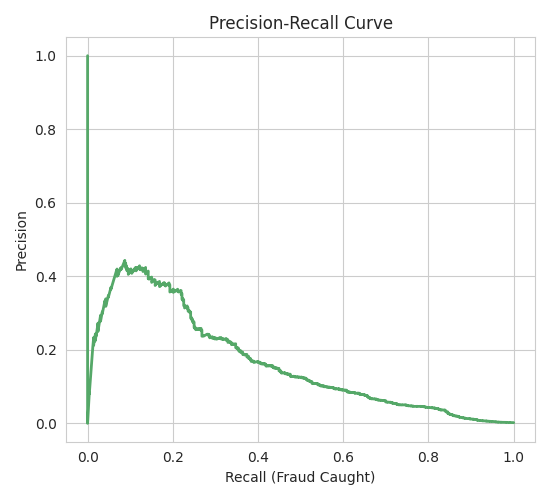

In [11]:
fig, ax = plt.subplots(figsize=(5.5,5))
ax.plot(rec, prec, color='#55A868', lw=2)
ax.set_xlabel('Recall (Fraud Caught)')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve')
plt.tight_layout()
plt.show()

## 7. Confusion Matrix at the Contamination-Rate Threshold

This uses Isolation Forest's default decision boundary (flagging the top ~0.17% most anomalous transactions, matching the true fraud rate) rather than a recall-tuned threshold.

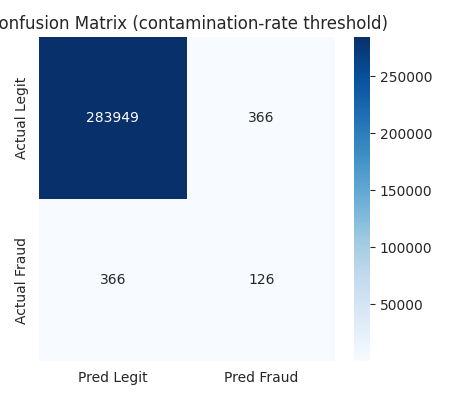

In [12]:
cm = confusion_matrix(y, preds_binary)
fig, ax = plt.subplots(figsize=(4.5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Pred Legit','Pred Fraud'], yticklabels=['Actual Legit','Actual Fraud'])
ax.set_title('Confusion Matrix (contamination-rate threshold)')
plt.tight_layout()
plt.show()

## 8. Summary

- Trained an **unsupervised Isolation Forest** on all 284,807 transactions with **no fraud labels used in training**.
- Achieved **0.947 ROC-AUC** despite the extreme class imbalance (0.17% fraud rate).
- Quantified the operational tradeoff between fraud recall and review-team workload: catching **80% of fraud requires flagging ~18.7x** as many transactions as there are actual frauds — a concrete way to frame the cost of raising transaction-monitoring sensitivity to a fraud-ops or risk team.
- This tradeoff table (rather than a single accuracy number) is the more decision-useful artifact for a real fraud team, since it lets them pick an operating point based on how much review capacity they actually have.

### Possible extensions
- Compare against a supervised baseline (e.g. XGBoost with labels) to quantify the cost of going label-free.
- Try Local Outlier Factor or a deep autoencoder as alternative unsupervised detectors.
- Cost-weight the threshold choice using estimated dollar loss per missed fraud vs. analyst-hour cost per false positive.
